In [2]:
!pip -q install -U kagglehub

import os
import getpass

# Paste the NEW token only into the hidden box that appears.
# Do not paste it into the code or chat.
os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Paste your Kaggle API token here: ")

Paste your Kaggle API token here: ··········


In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download("gti-upm/leapgestrecog")
print("Downloaded to:", dataset_path)

100%|██████████| 2.13G/2.13G [00:26<00:00, 85.5MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1


In [4]:
from pathlib import Path

dataset_folder = Path(dataset_path) / "leapGestRecog"

print("Dataset available:", dataset_folder.exists())
print("Person folders:", sorted(x.name for x in dataset_folder.iterdir()))

Dataset available: True
Person folders: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']


In [6]:
from pathlib import Path
import numpy as np

DATA_DIR = Path(dataset_path) / "leapGestRecog"

image_paths = sorted(DATA_DIR.glob("*/*/*.png"))

paths = np.array([str(path) for path in image_paths])
gesture_names = np.array([path.parent.name for path in image_paths])
person_ids = np.array([path.parent.parent.name for path in image_paths])

classes = sorted(np.unique(gesture_names))
class_to_id = {gesture: index for index, gesture in enumerate(classes)}
labels = np.array([class_to_id[gesture] for gesture in gesture_names])

print("Total images:", len(paths))
print("Gesture classes:")
print(classes)

Total images: 20000
Gesture classes:
[np.str_('01_palm'), np.str_('02_l'), np.str_('03_fist'), np.str_('04_fist_moved'), np.str_('05_thumb'), np.str_('06_index'), np.str_('07_ok'), np.str_('08_palm_moved'), np.str_('09_c'), np.str_('10_down')]


In [7]:
# Use different people for training and testing
train_mask = np.isin(person_ids, ["00", "01", "02", "03", "04", "05", "06", "07"])
val_mask = person_ids == "08"
test_mask = person_ids == "09"

train_paths, train_labels = paths[train_mask], labels[train_mask]
val_paths, val_labels = paths[val_mask], labels[val_mask]
test_paths, test_labels = paths[test_mask], labels[test_mask]

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Testing images:", len(test_paths))

Training images: 16000
Validation images: 2000
Testing images: 2000


In [8]:
import tensorflow as tf

IMAGE_SIZE = 64
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(image_paths, image_labels, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, image_labels))

    if shuffle:
        dataset = dataset.shuffle(len(image_paths), seed=42)

    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_paths, train_labels, shuffle=True)
val_ds = make_dataset(val_paths, val_labels)
test_ds = make_dataset(test_paths, test_labels)

In [9]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1)),

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(classes), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,666 (4.36 MB)

 Trainable params: 1,142,666 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
train_mask = np.isin(person_ids, ["00", "01", "02", "03", "04", "05", "06", "07"])
val_mask = person_ids == "08"
test_mask = person_ids == "09"

train_paths = paths[train_mask]
train_labels = labels[train_mask]

val_paths = paths[val_mask]
val_labels = labels[val_mask]

test_paths = paths[test_mask]
test_labels = labels[test_mask]

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Testing images:", len(test_paths))

Training images: 16000
Validation images: 2000
Testing images: 2000


In [13]:
history = model.fit(
    train_ds.take(75),
    validation_data=val_ds.take(15),
    epochs=3
)

Epoch 1/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 58s 767ms/step - accuracy: 0.9985 - loss: 0.0085 - val_accuracy: 0.4396 - val_loss: 5.6884
Epoch 2/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 52s 689ms/step - accuracy: 0.9977 - loss: 0.0067 - val_accuracy: 0.4313 - val_loss: 5.6864
Epoch 3/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 82s 690ms/step - accuracy: 0.9962 - loss: 0.0119 - val_accuracy: 0.4615 - val_loss: 5.1237


In [14]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy * 100, "%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step - accuracy: 0.8940 - loss: 0.5717
Test Accuracy: 89.3999993801117 %


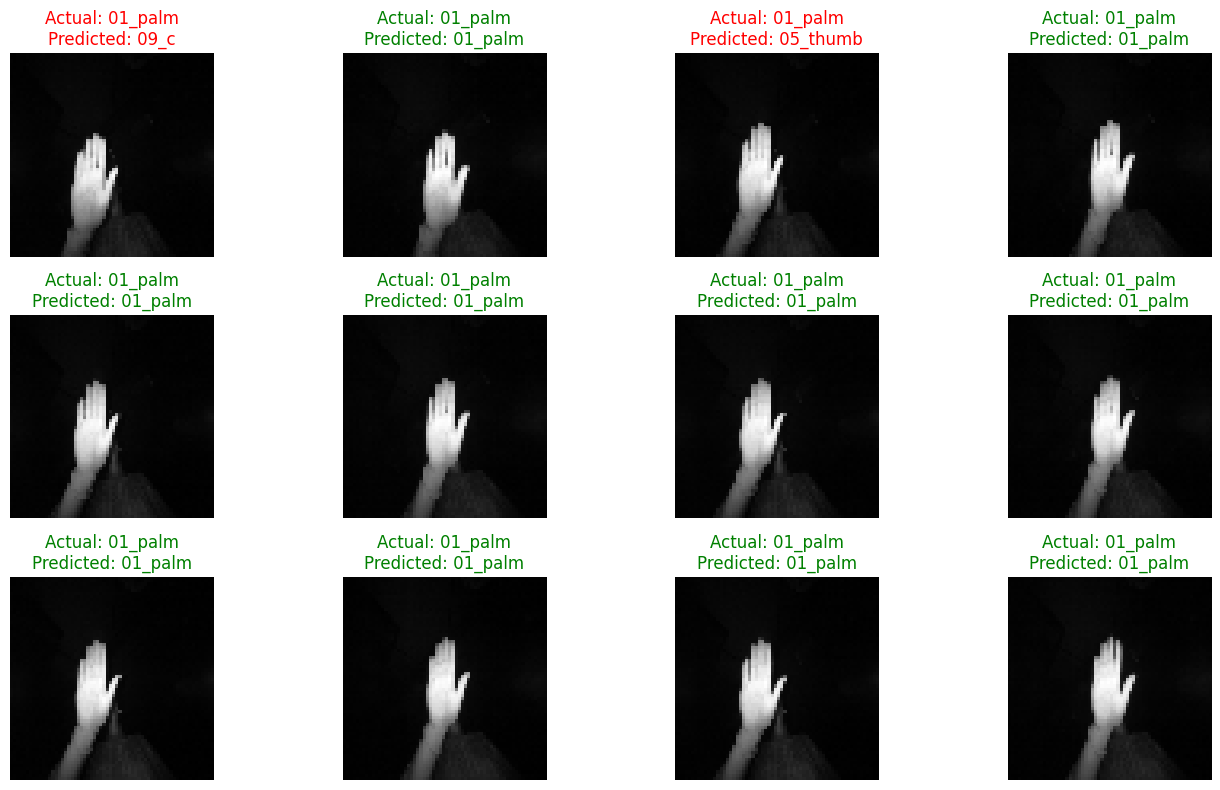

In [15]:
import matplotlib.pyplot as plt

images, actual_labels = next(iter(test_ds))
predictions = model.predict(images, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(14, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(images[i].numpy().squeeze(), cmap="gray")

    actual = classes[actual_labels[i].numpy()]
    predicted = classes[predicted_labels[i]]

    color = "green" if actual == predicted else "red"

    plt.title(f"Actual: {actual}\nPredicted: {predicted}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
model.save("hand_gesture_model.keras")